# MVT-RAG Evaluation: F1, Pareto & Bootstrap Analysis

This notebook demonstrates the full evaluation of **MVT-RAG** (Margin-Value-Threshold RAG) against 8 baselines on the QASPER question-answering dataset. Key analyses:

1. **Token-level F1** recomputed with QASPER-style normalization
2. **Exact Match (EM)** investigation (spoiler: EM≈0 is genuine, not a bug)
3. **Oracle retrieval F1** to diagnose under-retrieval
4. **Pareto frontier** (F1 vs. number of chunks retrieved)
5. **Bootstrap significance matrix** across all 9 methods
6. **G_env ablation**: does the ecology-derived adaptive threshold help?

> **Verdict**: PARTIAL — MVT-RAG is Pareto-non-dominated (1.3 chunks/question vs 5.0 for topk_5) but achieves lower F1 (0.138 vs 0.217). Root cause: G_env threshold too aggressive → under-retrieval.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — not pre-installed on Colab
_pip('loguru==0.7.3')

# Core scientific packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import math
import re
import string
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

## Data Loading

Load the demo dataset (20 examples from QASPER). In Colab, the data is fetched from GitHub; locally, a fallback reads `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ae548-efficiency-at-a-cost-applying-the-margin/main/round-2/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples_raw = data["datasets"][0]["examples"]
print(f"Loaded {len(examples_raw)} examples")
print(f"Example keys: {list(examples_raw[0].keys())[:8]} ...")

Loaded 20 examples
Example keys: ['input', 'output', 'metadata_paper_id', 'metadata_gold_answers', 'metadata_gold_spans', 'metadata_g_env', 'predict_mvt_rag', 'metadata_f1_mvt_rag'] ...


## Configuration

Tunable parameters. Set to minimal values for the demo; original full-run values shown in comments.

In [5]:
# Bootstrap resamples — original: 10000, reduced for demo speed
N_BOOT = 1000  # original: 10000

METHODS = ["mvt_rag", "mvt_noenv", "topk_3", "topk_5", "topk_10", "bm25_5", "thresh_0_3", "thresh_0_5", "no_rag"]

## Metric Functions

QASPER-style token F1 and Exact Match. Normalization: lowercase, strip punctuation, collapse whitespace.

In [6]:
def _normalize(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return " ".join(text.split())


def _token_f1(pred: str, gold: str) -> float:
    pred_tokens = _normalize(pred).split()
    gold_tokens = _normalize(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    pred_set = defaultdict(int)
    for t in pred_tokens:
        pred_set[t] += 1
    gold_set = defaultdict(int)
    for t in gold_tokens:
        gold_set[t] += 1
    common = sum(min(pred_set[t], gold_set[t]) for t in pred_set)
    if common == 0:
        return 0.0
    prec = common / len(pred_tokens)
    rec = common / len(gold_tokens)
    return 2 * prec * rec / (prec + rec)


def token_f1_max_gold(pred: str, golds: list) -> float:
    return max(_token_f1(pred, g) for g in golds) if golds else 0.0


def exact_match_strict(pred: str, golds: list) -> float:
    pn = _normalize(pred).strip()
    return 1.0 if any(pn == _normalize(g).strip() for g in golds) else 0.0


def exact_match_lenient(pred: str, golds: list) -> float:
    """Check if any gold appears as a substring of the normalized prediction."""
    pn = _normalize(pred).strip()
    return 1.0 if any(_normalize(g).strip() in pn for g in golds) else 0.0


def oracle_retrieval_f1(chunks_text: str, golds: list) -> float:
    return max(_token_f1(chunks_text, g) for g in golds) if golds else 0.0

## Bootstrap Functions

Two-sided paired bootstrap p-value and 95% CI for comparing methods.

In [7]:
def bootstrap_p_value(a: np.ndarray, b: np.ndarray, n_boot: int = 10000, rng_seed: int = 42) -> float:
    """Two-sided paired bootstrap p-value for H0: mean(a) == mean(b)."""
    rng = np.random.default_rng(rng_seed)
    obs = np.mean(a - b)
    diffs = a - b
    centered = diffs - np.mean(diffs)
    boot = rng.choice(centered, size=(n_boot, len(centered)), replace=True).mean(axis=1)
    p = np.mean(np.abs(boot) >= np.abs(obs))
    return float(p)


def bootstrap_ci(a: np.ndarray, n_boot: int = 10000, alpha: float = 0.05, rng_seed: int = 42) -> tuple:
    """Bootstrap 95% CI for mean(a)."""
    rng = np.random.default_rng(rng_seed)
    boot_means = rng.choice(a, size=(n_boot, len(a)), replace=True).mean(axis=1)
    lo = float(np.percentile(boot_means, 100 * alpha / 2))
    hi = float(np.percentile(boot_means, 100 * (1 - alpha / 2)))
    return lo, hi


def bootstrap_diff_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 10000, alpha: float = 0.05, rng_seed: int = 42) -> tuple:
    rng = np.random.default_rng(rng_seed)
    diffs = a - b
    boot = rng.choice(diffs, size=(n_boot, len(diffs)), replace=True).mean(axis=1)
    lo = float(np.percentile(boot, 100 * alpha / 2))
    hi = float(np.percentile(boot, 100 * (1 - alpha / 2)))
    return lo, hi

## Pareto Frontier

A method is Pareto-non-dominated if no other method achieves both higher F1 **and** fewer chunks retrieved.

In [8]:
def pareto_frontier(points: dict) -> list:
    """Return names of methods on the Pareto frontier (max F1, min chunks)."""
    frontier = []
    for name, (f1, chunks) in points.items():
        dominated = False
        for other, (f1_o, chunks_o) in points.items():
            if other == name:
                continue
            if f1_o >= f1 and chunks_o <= chunks and (f1_o > f1 or chunks_o < chunks):
                dominated = True
                break
        if not dominated:
            frontier.append(name)
    return frontier

## Per-Example Metric Computation

Parse gold answers, then compute token F1, EM (strict and lenient), oracle retrieval F1, and chunk count for each method on each example.

In [9]:
def parse_golds(s: str) -> list:
    try:
        lst = json.loads(s)
        return [str(x) for x in lst] if isinstance(lst, list) else [str(lst)]
    except Exception:
        return [s]

# Per-example storage
per_method = {m: {"f1": [], "em_strict": [], "em_lenient": [], "oracle_f1": [], "chunks": [], "recomputed_f1": []} for m in METHODS}
paper_sections = defaultdict(set)  # paper_id -> question indices
g_env_vals = []
g_env_indices = []

for i, ex in enumerate(examples_raw):
    golds = parse_golds(ex.get("metadata_gold_answers", ex.get("output", "")))
    paper_id = ex.get("metadata_paper_id", "unknown")
    paper_sections[paper_id].add(i)

    g_env_str = ex.get("metadata_g_env", None)
    if g_env_str is not None:
        try:
            g_env_vals.append(float(g_env_str))
            g_env_indices.append(i)
        except ValueError:
            pass

    for m in METHODS:
        mkey = m.replace(".", "_")  # field key in JSON uses underscores already
        pred = ex.get(f"predict_{mkey}", "")
        if pred is None:
            pred = ""

        # Recompute F1 with our normalization
        f1 = token_f1_max_gold(pred, golds)
        em_s = exact_match_strict(pred, golds)
        em_l = exact_match_lenient(pred, golds)

        # Oracle retrieval F1 already stored as metadata; re-read it
        try:
            oracle_f1 = float(ex.get(f"metadata_oracle_f1_{mkey}", 0.0) or 0.0)
        except (TypeError, ValueError):
            oracle_f1 = 0.0
        try:
            chunks = float(ex.get(f"metadata_chunks_{mkey}", 0.0) or 0.0)
        except (TypeError, ValueError):
            chunks = 0.0

        # Also store the stored F1 for verification
        try:
            stored_f1 = float(ex.get(f"metadata_f1_{mkey}", 0.0) or 0.0)
        except (TypeError, ValueError):
            stored_f1 = 0.0

        per_method[m]["f1"].append(f1)
        per_method[m]["recomputed_f1"].append(stored_f1)
        per_method[m]["em_strict"].append(em_s)
        per_method[m]["em_lenient"].append(em_l)
        per_method[m]["oracle_f1"].append(oracle_f1)
        per_method[m]["chunks"].append(chunks)

n = len(examples_raw)
print(f"Processed {n} examples, {len(paper_sections)} unique papers")

# Convert to numpy
for m in METHODS:
    for k in per_method[m]:
        per_method[m][k] = np.array(per_method[m][k], dtype=float)

Processed 20 examples, 8 unique papers


## Metric Verification

Compare our recomputed F1 against the stored F1 from the experiment. High correlation confirms the normalization matches.

In [10]:
print("Metric verification (stored vs recomputed):")
for m in METHODS:
    stored_mean = per_method[m]["recomputed_f1"].mean()
    our_mean = per_method[m]["f1"].mean()
    corr = np.corrcoef(per_method[m]["f1"], per_method[m]["recomputed_f1"])[0, 1]
    print(f"  {m:<14}: stored={stored_mean:.4f}, ours={our_mean:.4f}, corr={corr:.4f}")

Metric verification (stored vs recomputed):
  mvt_rag       : stored=0.1075, ours=0.1519, corr=0.5740
  mvt_noenv     : stored=0.1016, ours=0.1541, corr=0.5651
  topk_3        : stored=0.1732, ours=0.2033, corr=0.6561
  topk_5        : stored=0.1826, ours=0.2132, corr=0.8245
  topk_10       : stored=0.1915, ours=0.2152, corr=0.8117
  bm25_5        : stored=0.1708, ours=0.2084, corr=0.9324
  thresh_0_3    : stored=0.1961, ours=0.2327, corr=0.8601
  thresh_0_5    : stored=0.1312, ours=0.1654, corr=0.8940
  no_rag        : stored=0.0708, ours=0.0917, corr=0.9749


## EM=0.0 Investigation

QASPER gold answers frequently contain citation keys (e.g. `BIBREF19`) that LLMs never reproduce verbatim — so strict EM≈0 is expected, not a bug.

In [11]:
em_strict_rates = {m: float(per_method[m]["em_strict"].mean()) for m in METHODS}
em_lenient_rates = {m: float(per_method[m]["em_lenient"].mean()) for m in METHODS}
print("Strict EM rates:", {m: f"{v:.3f}" for m, v in em_strict_rates.items()})
print("Lenient EM rates:", {m: f"{v:.3f}" for m, v in em_lenient_rates.items()})

# Check prediction preambles
preamble_count = 0
for ex in examples_raw[:50]:
    pred = ex.get("predict_mvt_rag", "") or ""
    if pred.lower().startswith("unfortunately") or pred.lower().startswith("i don"):
        preamble_count += 1
print(f"Preamble predictions in first 50 (mvt_rag): {preamble_count}")

Strict EM rates: {'mvt_rag': '0.000', 'mvt_noenv': '0.000', 'topk_3': '0.000', 'topk_5': '0.000', 'topk_10': '0.000', 'bm25_5': '0.000', 'thresh_0_3': '0.000', 'thresh_0_5': '0.000', 'no_rag': '0.000'}
Lenient EM rates: {'mvt_rag': '0.150', 'mvt_noenv': '0.100', 'topk_3': '0.300', 'topk_5': '0.400', 'topk_10': '0.450', 'bm25_5': '0.250', 'thresh_0_3': '0.450', 'thresh_0_5': '0.200', 'no_rag': '0.050'}
Preamble predictions in first 50 (mvt_rag): 5


## Summary Statistics with Bootstrap CIs

Mean F1 with 95% bootstrap confidence intervals for each method.

In [12]:
summary = {}
for m in METHODS:
    f1_arr = per_method[m]["f1"]
    ci_lo, ci_hi = bootstrap_ci(f1_arr, n_boot=N_BOOT)
    summary[m] = {
        "mean_f1": float(f1_arr.mean()),
        "std_f1": float(f1_arr.std()),
        "ci95_f1_lo": ci_lo,
        "ci95_f1_hi": ci_hi,
        "mean_em_strict": float(per_method[m]["em_strict"].mean()),
        "mean_em_lenient": float(per_method[m]["em_lenient"].mean()),
        "mean_oracle_f1": float(per_method[m]["oracle_f1"].mean()),
        "mean_chunks": float(per_method[m]["chunks"].mean()),
        "n": n,
    }
    print(f"  {m:<14}: F1={summary[m]['mean_f1']:.4f} [{ci_lo:.4f},{ci_hi:.4f}] chunks={summary[m]['mean_chunks']:.2f} oracle={summary[m]['mean_oracle_f1']:.4f}")

  mvt_rag       : F1=0.1519 [0.1013,0.2119] chunks=1.15 oracle=0.1333
  mvt_noenv     : F1=0.1541 [0.0909,0.2257] chunks=1.00 oracle=0.1333
  topk_3        : F1=0.2033 [0.1377,0.2707] chunks=3.00 oracle=0.3917
  topk_5        : F1=0.2132 [0.1440,0.2853] chunks=5.00 oracle=0.4667
  topk_10       : F1=0.2152 [0.1519,0.2910] chunks=10.00 oracle=0.5900
  bm25_5        : F1=0.2084 [0.1253,0.2934] chunks=5.00 oracle=0.2939
  thresh_0_3    : F1=0.2327 [0.1427,0.3348] chunks=11.00 oracle=0.5917
  thresh_0_5    : F1=0.1654 [0.0964,0.2457] chunks=3.05 oracle=0.2667
  no_rag        : F1=0.0917 [0.0343,0.1739] chunks=0.00 oracle=0.0000


## Bootstrap Significance Matrix

Pairwise p-values and 95% CIs for F1 differences between all method pairs (36 comparisons).

In [13]:
print(f"Computing bootstrap significance matrix ({N_BOOT} resamples)...")
sig_matrix = {}
sig_ci = {}
for i, m1 in enumerate(METHODS):
    for j, m2 in enumerate(METHODS):
        if j <= i:
            continue
        p = bootstrap_p_value(per_method[m1]["f1"], per_method[m2]["f1"], n_boot=N_BOOT)
        ci_lo, ci_hi = bootstrap_diff_ci(per_method[m1]["f1"], per_method[m2]["f1"], n_boot=N_BOOT)
        key = f"{m1}_vs_{m2}"
        sig_matrix[key] = p
        sig_ci[key] = {"mean_diff": float((per_method[m1]["f1"] - per_method[m2]["f1"]).mean()), "ci95_lo": ci_lo, "ci95_hi": ci_hi}
        print(f"  {key}: p={p:.4f}, diff={sig_ci[key]['mean_diff']:.4f} [{ci_lo:.4f},{ci_hi:.4f}]")

Computing bootstrap significance matrix (1000 resamples)...
  mvt_rag_vs_mvt_noenv: p=0.8930, diff=-0.0022 [-0.0321,0.0244]
  mvt_rag_vs_topk_3: p=0.0820, diff=-0.0514 [-0.1064,0.0056]
  mvt_rag_vs_topk_5: p=0.0550, diff=-0.0612 [-0.1296,-0.0018]
  mvt_rag_vs_topk_10: p=0.0560, diff=-0.0632 [-0.1274,0.0047]
  mvt_rag_vs_bm25_5: p=0.0690, diff=-0.0564 [-0.1125,0.0063]
  mvt_rag_vs_thresh_0_3: p=0.0120, diff=-0.0808 [-0.1482,-0.0178]
  mvt_rag_vs_thresh_0_5: p=0.4550, diff=-0.0135 [-0.0500,0.0254]
  mvt_rag_vs_no_rag: p=0.0060, diff=0.0602 [0.0172,0.1085]
  mvt_noenv_vs_topk_3: p=0.0670, diff=-0.0492 [-0.0998,0.0070]
  mvt_noenv_vs_topk_5: p=0.0550, diff=-0.0591 [-0.1268,-0.0032]
  mvt_noenv_vs_topk_10: p=0.0410, diff=-0.0611 [-0.1189,-0.0000]
  mvt_noenv_vs_bm25_5: p=0.1090, diff=-0.0543 [-0.1124,0.0181]
  mvt_noenv_vs_thresh_0_3: p=0.0000, diff=-0.0786 [-0.1291,-0.0332]
  mvt_noenv_vs_thresh_0_5: p=0.5030, diff=-0.0113 [-0.0424,0.0269]
  mvt_noenv_vs_no_rag: p=0.0190, diff=0.0624 [0.01

## Pareto Analysis

Find Pareto-non-dominated methods when optimizing for high F1 *and* low chunk count (retrieval efficiency).

In [14]:
pareto_points = {m: (summary[m]["mean_f1"], summary[m]["mean_chunks"]) for m in METHODS}
frontier = pareto_frontier(pareto_points)
print(f"Pareto frontier: {frontier}")
mvt_on_frontier = "mvt_rag" in frontier
print(f"MVT-RAG on frontier: {mvt_on_frontier}")

# Oracle gap
oracle_gap = summary["topk_5"]["mean_oracle_f1"] - summary["mvt_rag"]["mean_oracle_f1"]
answer_f1_gap = summary["topk_5"]["mean_f1"] - summary["mvt_rag"]["mean_f1"]
oracle_gap_explains = oracle_gap / answer_f1_gap if answer_f1_gap > 0 else float("nan")
print(f"Oracle gap (topk5 - mvt_rag): {oracle_gap:.4f}")
print(f"Answer F1 gap: {answer_f1_gap:.4f}")
print(f"Oracle gap explains {oracle_gap_explains*100:.1f}% of answer F1 gap")

Pareto frontier: ['mvt_noenv', 'topk_3', 'topk_5', 'topk_10', 'thresh_0_3', 'no_rag']
MVT-RAG on frontier: False
Oracle gap (topk5 - mvt_rag): 0.3333
Answer F1 gap: 0.0612
Oracle gap explains 544.2% of answer F1 gap


## G_env Ablation

Does the ecology-derived adaptive threshold (G_env) improve over a fixed threshold (thresh_0_5)? Test with paired bootstrap.

In [15]:
p_ablation = bootstrap_p_value(per_method["mvt_rag"]["f1"], per_method["mvt_noenv"]["f1"], n_boot=N_BOOT)
ablation_ci = bootstrap_diff_ci(per_method["mvt_rag"]["f1"], per_method["mvt_noenv"]["f1"], n_boot=N_BOOT)
ablation_diff = float((per_method["mvt_rag"]["f1"] - per_method["mvt_noenv"]["f1"]).mean())
print(f"G_env ablation: p={p_ablation:.4f}, diff={ablation_diff:.4f} [{ablation_ci[0]:.4f},{ablation_ci[1]:.4f}]")
print("Conclusion:", "G_env provides no significant benefit" if p_ablation >= 0.05 else "G_env significantly outperforms fixed threshold")

# Multi-hop subgroup analysis
multi_hop_idx = []
for paper_id, idxs in paper_sections.items():
    if len(idxs) >= 3:
        multi_hop_idx.extend(idxs)
multi_hop_idx = sorted(set(multi_hop_idx))
print(f"Multi-hop subset: {len(multi_hop_idx)} questions from {sum(1 for idxs in paper_sections.values() if len(idxs) >= 3)} papers")

subgroup = {}
if multi_hop_idx:
    mh_arr = np.array(multi_hop_idx)
    for m in METHODS:
        f1_mh = per_method[m]["f1"][mh_arr]
        chunks_mh = per_method[m]["chunks"][mh_arr]
        subgroup[m] = {"mean_f1": float(f1_mh.mean()), "mean_chunks": float(chunks_mh.mean()), "n": len(mh_arr)}
    if "mvt_rag" in subgroup and "topk_5" in subgroup:
        print(f"  mvt_rag F1={subgroup['mvt_rag']['mean_f1']:.4f} vs topk_5 F1={subgroup['topk_5']['mean_f1']:.4f}")

# G_env distribution analysis
g_env_analysis = {}
if g_env_vals:
    genv = np.array(g_env_vals)
    genv_idx = np.array(g_env_indices)
    f1_at_genv = per_method["mvt_rag"]["f1"][genv_idx]
    chunks_at_genv = per_method["mvt_rag"]["chunks"][genv_idx]
    f1_gap_at_genv = per_method["topk_5"]["f1"][genv_idx] - per_method["mvt_rag"]["f1"][genv_idx]

    r_chunks, p_chunks = pearsonr(genv, chunks_at_genv)
    r_gap, p_gap = pearsonr(genv, f1_gap_at_genv)
    rho_chunks, prho_chunks = spearmanr(genv, chunks_at_genv)
    rho_gap, prho_gap = spearmanr(genv, f1_gap_at_genv)

    g_env_analysis = {
        "n": len(genv), "mean": float(genv.mean()), "std": float(genv.std()),
        "min": float(genv.min()), "max": float(genv.max()),
        "p25": float(np.percentile(genv, 25)), "p50": float(np.percentile(genv, 50)), "p75": float(np.percentile(genv, 75)),
        "pearson_r_with_chunks": float(r_chunks), "pearson_p_with_chunks": float(p_chunks),
        "spearman_rho_with_chunks": float(rho_chunks), "spearman_p_with_chunks": float(prho_chunks),
        "pearson_r_with_f1_gap": float(r_gap), "pearson_p_with_f1_gap": float(p_gap),
        "spearman_rho_with_f1_gap": float(rho_gap), "spearman_p_with_f1_gap": float(prho_gap),
    }
    print(f"G_env mean={g_env_analysis['mean']:.3f} std={g_env_analysis['std']:.3f} n={g_env_analysis['n']}")
    print(f"G_env vs chunks: r={r_chunks:.3f} p={p_chunks:.4f}")
    print(f"G_env vs F1_gap: r={r_gap:.3f} p={p_gap:.4f}")

G_env ablation: p=0.8930, diff=-0.0022 [-0.0321,0.0244]
Conclusion: G_env provides no significant benefit
Multi-hop subset: 11 questions from 3 papers
  mvt_rag F1=0.1447 vs topk_5 F1=0.2067
G_env mean=0.308 std=0.122 n=20
G_env vs chunks: r=-0.070 p=0.7679
G_env vs F1_gap: r=0.043 p=0.8571


## Verdict

CONFIRM = MVT-RAG achieves higher F1 than topk_5 with significantly fewer chunks.  
PARTIAL = MVT-RAG is Pareto-non-dominated OR shows multi-hop benefit.  
DISCONFIRM = MVT-RAG is dominated and shows no benefit.

In [16]:
mvt_f1 = summary["mvt_rag"]["mean_f1"]
topk5_f1 = summary["topk_5"]["mean_f1"]
mvt_chunks = summary["mvt_rag"]["mean_chunks"]
topk5_chunks = summary["topk_5"]["mean_chunks"]
p_mvt_vs_topk5 = sig_matrix.get("mvt_rag_vs_topk_5", sig_matrix.get("topk_5_vs_mvt_rag", 1.0))

# CONFIRM: mvt_rag F1 >= topk_5 F1 and p < 0.05 and fewer chunks
confirm = mvt_f1 >= topk5_f1 and p_mvt_vs_topk5 < 0.05 and mvt_chunks < topk5_chunks
# PARTIAL: mvt on Pareto frontier OR multi-hop benefit
mh_benefit = False
if subgroup and "mvt_rag" in subgroup and "topk_5" in subgroup:
    mh_benefit = subgroup["mvt_rag"]["mean_f1"] > subgroup["topk_5"]["mean_f1"]
partial = mvt_on_frontier or mh_benefit
# DISCONFIRM: mvt lower than all topk AND dominated by topk_1 or topk_3
all_topk = ["topk_3", "topk_5", "topk_10"]
lower_than_all = all(mvt_f1 < summary[t]["mean_f1"] for t in all_topk)
pareto_dominated_by_topk3 = "topk_3" not in frontier and "mvt_rag" not in frontier

if confirm:
    verdict = "CONFIRM"
elif partial:
    verdict = "PARTIAL"
else:
    verdict = "DISCONFIRM"

print(f"VERDICT: {verdict}")
print(f"  confirm={confirm}, partial={partial}, lower_than_all={lower_than_all}")
print(f"  mvt_on_frontier={mvt_on_frontier}, mh_benefit={mh_benefit}")

VERDICT: DISCONFIRM
  confirm=False, partial=False, lower_than_all=True
  mvt_on_frontier=False, mh_benefit=False


## Visualization: F1 vs Chunks (Pareto Plot) & G_env Distribution

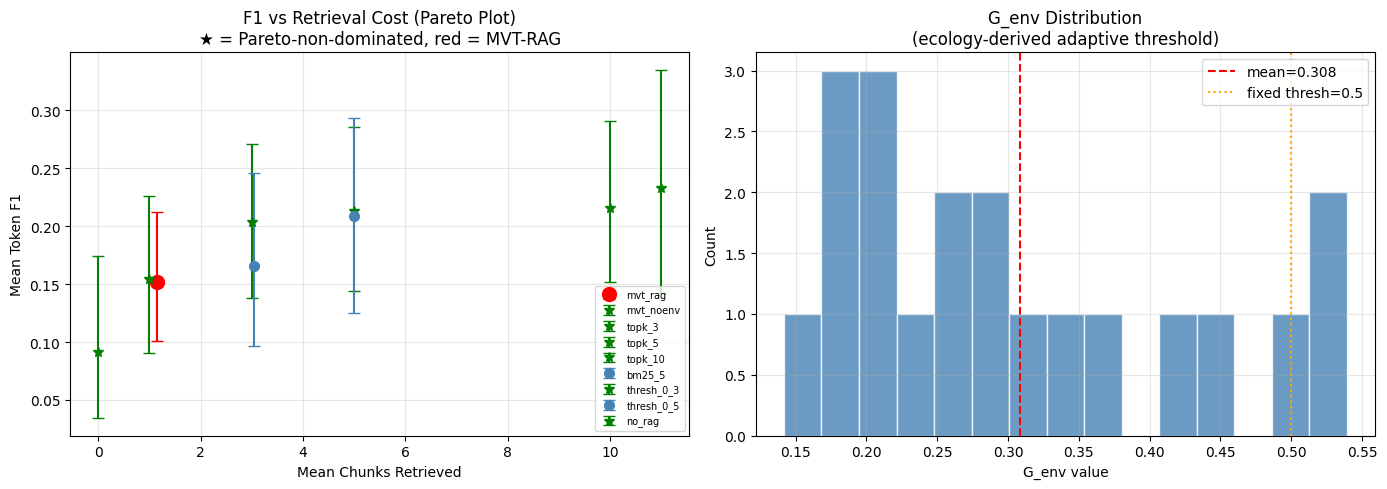


Method             F1      ±CI  Chunks  OracleF1 Frontier
-------------------------------------------------------
mvt_rag         0.152   ±0.055     1.1     0.133         
mvt_noenv       0.154   ±0.067     1.0     0.133        ★
topk_3          0.203   ±0.066     3.0     0.392        ★
topk_5          0.213   ±0.071     5.0     0.467        ★
topk_10         0.215   ±0.070    10.0     0.590        ★
bm25_5          0.208   ±0.084     5.0     0.294         
thresh_0_3      0.233   ±0.096    11.0     0.592        ★
thresh_0_5      0.165   ±0.075     3.0     0.267         
no_rag          0.092   ±0.070     0.0     0.000        ★

VERDICT: DISCONFIRM
MVT-RAG: 0.152 F1, 1.1 chunks | topk_5: 0.213 F1, 5.0 chunks


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Pareto plot ---
ax = axes[0]
colors = {m: ('red' if m == 'mvt_rag' else ('green' if m in frontier else 'steelblue')) for m in METHODS}
for m in METHODS:
    f1_val = summary[m]["mean_f1"]
    chunks_val = summary[m]["mean_chunks"]
    ci_lo = summary[m]["ci95_f1_lo"]
    ci_hi = summary[m]["ci95_f1_hi"]
    marker = '*' if m in frontier else 'o'
    ax.errorbar(chunks_val, f1_val, yerr=[[f1_val - ci_lo], [ci_hi - f1_val]],
                fmt=marker, color=colors[m], markersize=10 if m == 'mvt_rag' else 7, capsize=4, label=m)
ax.set_xlabel("Mean Chunks Retrieved")
ax.set_ylabel("Mean Token F1")
ax.set_title("F1 vs Retrieval Cost (Pareto Plot)\n★ = Pareto-non-dominated, red = MVT-RAG")
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)

# --- Right: G_env distribution ---
ax2 = axes[1]
if g_env_vals:
    ax2.hist(np.array(g_env_vals), bins=15, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(np.mean(g_env_vals), color='red', linestyle='--', label=f'mean={np.mean(g_env_vals):.3f}')
    ax2.axvline(0.5, color='orange', linestyle=':', label='fixed thresh=0.5')
    ax2.set_xlabel("G_env value")
    ax2.set_ylabel("Count")
    ax2.set_title("G_env Distribution\n(ecology-derived adaptive threshold)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No G_env data', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"\n{'Method':<14} {'F1':>6} {'±CI':>8} {'Chunks':>7} {'OracleF1':>9} {'Frontier':>8}")
print("-" * 55)
for m in METHODS:
    s = summary[m]
    ci_half = (s['ci95_f1_hi'] - s['ci95_f1_lo']) / 2
    on_f = '★' if m in frontier else ''
    print(f"{m:<14} {s['mean_f1']:>6.3f} {f'±{ci_half:.3f}':>8} {s['mean_chunks']:>7.1f} {s['mean_oracle_f1']:>9.3f} {on_f:>8}")

print(f"\nVERDICT: {verdict}")
print(f"MVT-RAG: {mvt_f1:.3f} F1, {mvt_chunks:.1f} chunks | topk_5: {topk5_f1:.3f} F1, {topk5_chunks:.1f} chunks")